In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error

In [3]:
df = pd.read_csv("/content/used_cars.csv")

In [4]:
df.head(10)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"
5,Acura,ILX 2.4L,2016,"136,397 mi.",Gasoline,2.4 Liter,F,Silver,Ebony.,None reported,NaN,"$14,798"
6,Audi,S3 2.0T Premium Plus,2017,"84,000 mi.",Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes,"$31,000"
7,BMW,740 iL,2001,"242,000 mi.",Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,Yes,"$7,300"
8,Lexus,RC 350 F Sport,2021,"23,436 mi.",Gasoline,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Black,None reported,Yes,"$41,927"
9,Tesla,Model X Long Range Plus,2020,"34,000 mi.",NaN,534.0HP Electric Motor Electric Fuel System,A/T,Black,Black,None reported,Yes,"$69,950"


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [6]:
LE = LabelEncoder()
df['brand'] = LE.fit_transform(df['brand'])
df['model'] = LE.fit_transform(df['model'])
df['milage']  =LE.fit_transform(df['milage'])
df['fuel_type'] = LE.fit_transform(df['fuel_type'])
df['engine'] = LE.fit_transform(df['engine'])
df['transmission'] = LE.fit_transform(df['transmission'])
df['ext_col'] = LE.fit_transform(df['ext_col'])
df['int_col'] = LE.fit_transform(df['int_col'])
df['accident'] = LE.fit_transform(df['accident'])
df['clean_title'] = LE.fit_transform(df['clean_title'])
df['price'] = LE.fit_transform(df['price'])

In [20]:
SS = StandardScaler()
df['model'] = SS.fit_transform(df[['model']])
df['model_year'] = SS.fit_transform(df[['model_year']])
df['milage'] = SS.fit_transform(df[['milage']])
df['engine'] = SS.fit_transform(df[['engine']])
df['ext_col'] = SS.fit_transform(df[['ext_col']])
df['int_col'] = SS.fit_transform(df[['int_col']])
df['price'] = SS.fit_transform(df[['price']])

In [21]:
df.head(10)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,14,1.488560,-0.412118,0.572994,1,-0.051771,16,-1.142637,-0.591724,0,0,-1.648692
1,19,0.465339,0.898486,0.063176,2,-0.100882,32,0.245704,0.718604,0,0,0.162630
2,27,0.726160,1.062312,-0.449076,2,-0.182734,40,-1.062540,-0.591724,1,1,0.929044
3,20,0.574774,-0.084467,1.466089,3,0.416422,23,-1.142637,-0.591724,1,0,-1.200874
4,3,0.543768,0.898486,1.520843,2,-1.299194,32,-0.332771,-0.591724,1,1,0.002217
5,0,-0.090958,0.079359,-1.149924,2,-1.273001,52,0.939875,0.488722,1,1,-1.276625
6,3,0.972390,0.243184,1.379700,2,-0.346438,16,-1.062540,-0.591724,1,0,-0.229489
7,4,-1.458901,-2.378024,-0.315234,2,-0.438112,38,-0.252675,0.787568,1,0,1.338986
8,27,0.667795,0.898486,-0.388239,2,0.115207,16,-1.142637,-0.591724,1,0,0.392108
9,52,0.321249,0.734661,0.044924,7,1.349533,38,-1.142637,-0.591724,1,0,1.321162


In [22]:
df.shape

(4009, 12)

In [23]:
df.describe()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
count,4009.000000,4.009000e+03,4.009000e+03,4.009000e+03,4009.000000,4.009000e+03,4009.000000,4.009000e+03,4.009000e+03,4009.000000,4009.000000,4.009000e+03
mean,23.635819,-1.063421e-17,-1.135734e-14,1.772369e-17,2.231230,-9.216319e-17,31.178848,-9.570793e-17,6.380528e-17,0.782240,0.148666,5.317107e-18
std,16.380885,1.000125e+00,1.000125e+00,1.000125e+00,1.193237,1.000125e+00,15.141472,1.000125e+00,1.000125e+00,0.476204,0.355803,1.000125e+00
min,0.000000,-1.690539e+00,-6.801313e+00,-1.718147e+00,0.000000,-1.954009e+00,0.000000,-1.400726e+00,-9.135590e-01,0.000000,0.000000,-1.664287e+00
25%,9.000000,-8.150555e-01,-5.759434e-01,-8.858896e-01,2.000000,-8.473715e-01,20.000000,-1.098139e+00,-5.917241e-01,1.000000,0.000000,-8.689101e-01
50%,21.000000,-5.995109e-02,2.431843e-01,3.032346e-02,2.000000,2.353268e-02,32.000000,-2.615743e-01,-5.917241e-01,1.000000,0.000000,-3.342977e-02
75%,36.000000,8.720740e-01,7.346608e-01,8.637975e-01,2.000000,8.355035e-01,38.000000,9.398747e-01,7.186036e-01,1.000000,0.000000,8.532934e-01
max,56.000000,1.769444e+00,1.389963e+00,1.709439e+00,7.000000,1.794808e+00,61.000000,1.429354e+00,2.649613e+00,2.000000,1.000000,1.829134e+00


In [24]:
df.isnull().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,0
engine,0
transmission,0
ext_col,0
int_col,0
accident,0


In [25]:
X = df.drop(columns = 'price',axis = 1)
Y = df['price']

In [26]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2,random_state = 42)

In [27]:
model = LinearRegression()

In [28]:
model.fit(X_train,Y_train)

LinearRegression()

In [29]:
y_pred = model.predict(X_test)

In [30]:
r2 = r2_score(Y_test,y_pred)
mse = mean_squared_error(Y_test,y_pred)

In [31]:
r2

0.06044070383269551

In [32]:
mse

0.9036982128246268

In [36]:
input = [[3,0.543768,0.898486,1.520843,2,-1.299194,32,-0.332771,-0.591724,1,1]]

In [37]:
new_pred_price = model.predict(input)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [38]:
print("New Predicted car Price :",new_pred_price[0])

New Predicted car Price : -0.2839880730386017


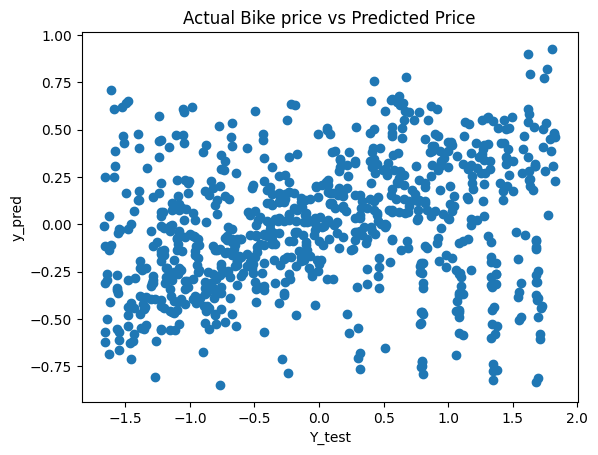

In [39]:
plt.scatter(Y_test,y_pred)
plt.xlabel("Y_test")
plt.ylabel("y_pred")
plt.title("Actual Bike price vs Predicted Price")
plt.show()